# Generative Adversarial Networks (GAN)

GAN adalah arsitektur jaringan saraf yang terdiri dari dua komponen utama: **Generator** dan **Discriminator**.  
- **Generator** bertugas membuat data palsu yang menyerupai data asli.  
- **Discriminator** bertugas membedakan antara data asli dan data buatan Generator.  

Keduanya dilatih secara bersamaan dalam permainan minimax:  
- Generator belajar menipu Discriminator  
- Discriminator belajar menjadi lebih baik dalam membedakan  

Tujuannya adalah membuat Generator menghasilkan data yang sangat mirip dengan data asli.


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
from torchvision.utils import save_image, make_grid

# Cek device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [26]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

batch_size = 128

trainset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)


In [27]:
# Generator
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [28]:
z_dim = 100
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

loss_fn = nn.BCELoss()
lr = 0.0002

optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)


Epoch 1/30 | D Loss: 0.1067 | G Loss: 5.0746
Epoch 2/30 | D Loss: 0.2316 | G Loss: 6.0294
Epoch 3/30 | D Loss: 0.6921 | G Loss: 2.9666
Epoch 4/30 | D Loss: 0.1472 | G Loss: 3.6798
Epoch 5/30 | D Loss: 1.1677 | G Loss: 1.7898


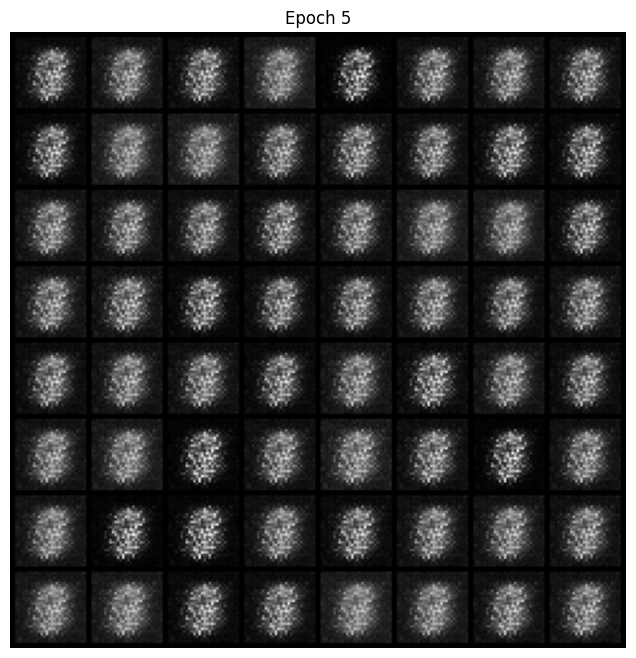

Epoch 6/30 | D Loss: 0.8606 | G Loss: 2.0051
Epoch 7/30 | D Loss: 0.1480 | G Loss: 2.8251
Epoch 8/30 | D Loss: 0.3596 | G Loss: 4.0048
Epoch 9/30 | D Loss: 0.0535 | G Loss: 4.4562
Epoch 10/30 | D Loss: 0.0717 | G Loss: 5.8997


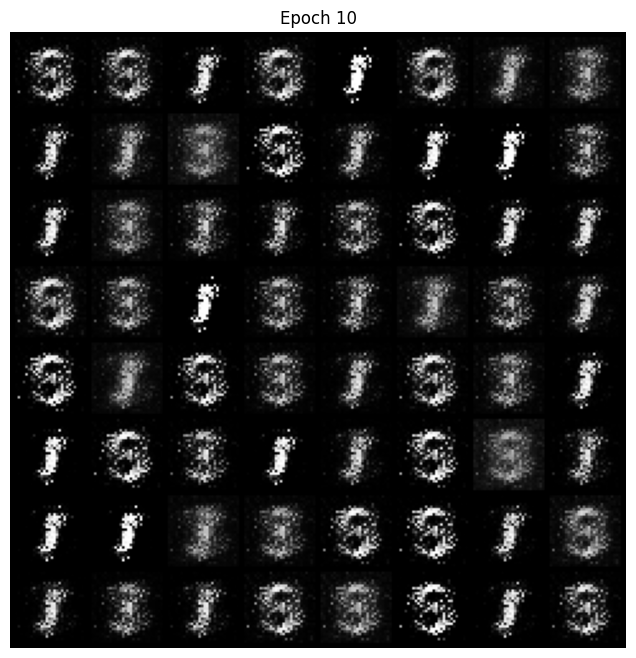

Epoch 11/30 | D Loss: 0.2421 | G Loss: 6.8554
Epoch 12/30 | D Loss: 0.1545 | G Loss: 5.0257
Epoch 13/30 | D Loss: 0.2983 | G Loss: 7.1179
Epoch 14/30 | D Loss: 0.1904 | G Loss: 6.9107
Epoch 15/30 | D Loss: 0.1443 | G Loss: 5.2467


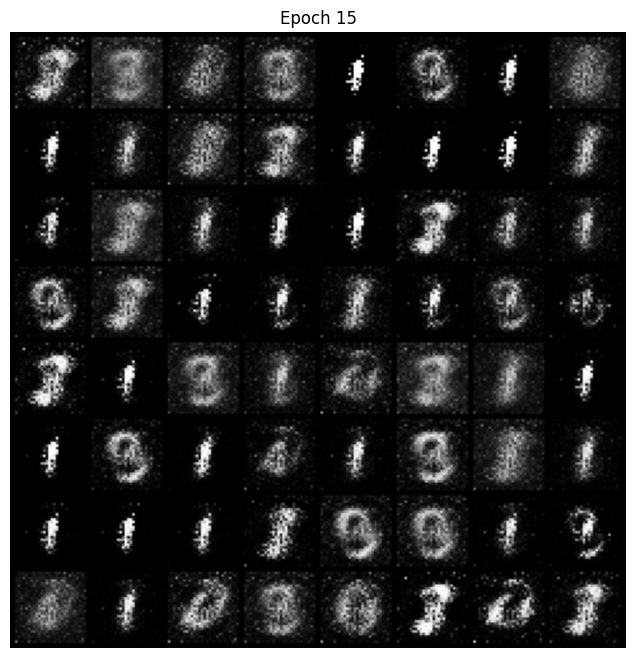

Epoch 16/30 | D Loss: 0.3198 | G Loss: 3.6637
Epoch 17/30 | D Loss: 0.2274 | G Loss: 4.5073
Epoch 18/30 | D Loss: 0.3246 | G Loss: 5.7449
Epoch 19/30 | D Loss: 0.3342 | G Loss: 3.0729
Epoch 20/30 | D Loss: 0.5015 | G Loss: 2.9645


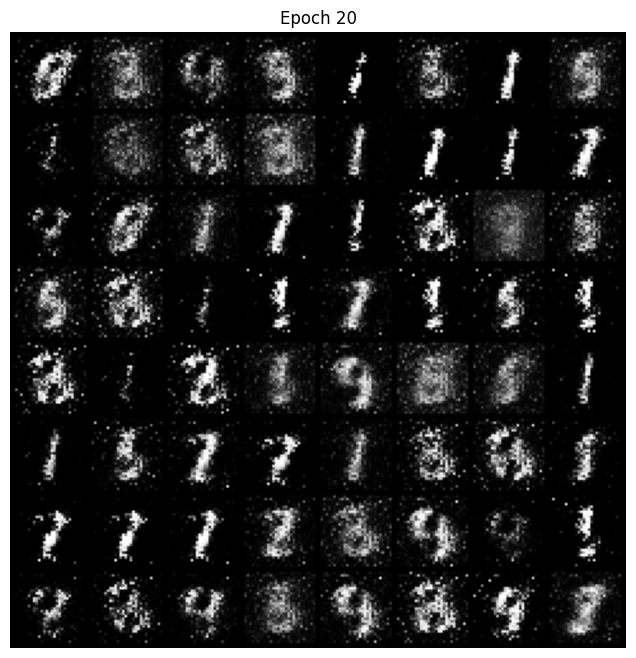

Epoch 21/30 | D Loss: 0.2352 | G Loss: 4.4128
Epoch 22/30 | D Loss: 0.2413 | G Loss: 4.8522
Epoch 23/30 | D Loss: 0.5438 | G Loss: 4.5341
Epoch 24/30 | D Loss: 0.3791 | G Loss: 2.9986
Epoch 25/30 | D Loss: 0.4216 | G Loss: 3.4806


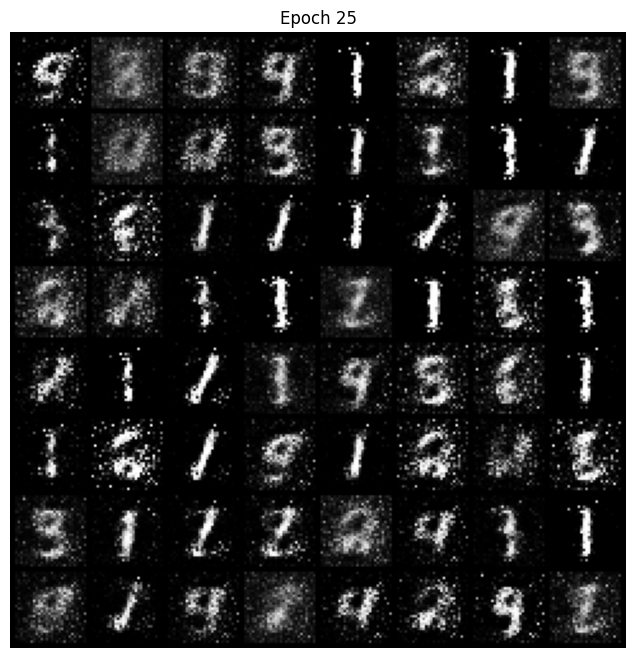

Epoch 26/30 | D Loss: 0.3452 | G Loss: 4.3844
Epoch 27/30 | D Loss: 0.6846 | G Loss: 6.5365
Epoch 28/30 | D Loss: 0.3231 | G Loss: 3.4975
Epoch 29/30 | D Loss: 0.2777 | G Loss: 3.5028
Epoch 30/30 | D Loss: 0.3465 | G Loss: 3.5784


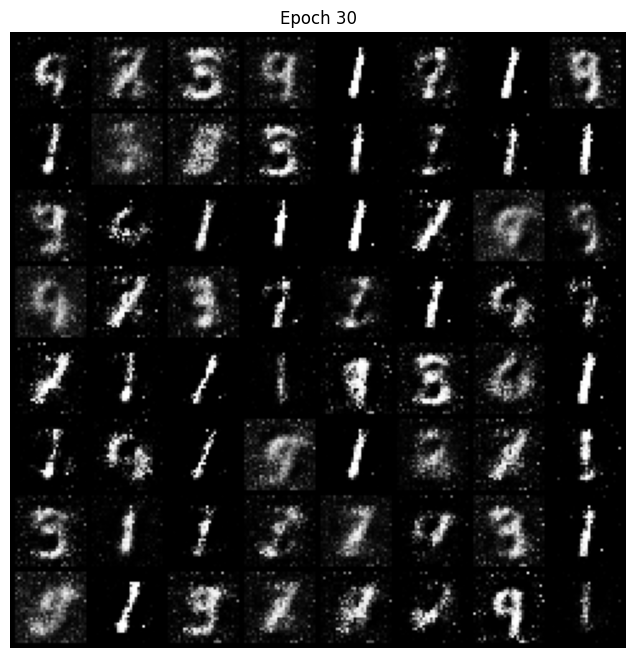

In [29]:
import os

output_dir = "/kaggle/working/generated_images"
os.makedirs(output_dir, exist_ok=True)

epochs = 30
fixed_noise = torch.randn(64, z_dim).to(device)

G_losses = []
D_losses = []

for epoch in range(epochs):
    for real, _ in trainloader:
        real = real.to(device)
        batch_size = real.size(0)

        # Label
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        ## Train Discriminator
        z = torch.randn(batch_size, z_dim).to(device)
        fake = G(z)

        D_real = D(real)
        D_fake = D(fake.detach())

        D_loss = loss_fn(D_real, real_labels) + loss_fn(D_fake, fake_labels)
        optimizer_D.zero_grad()
        D_loss.backward()
        optimizer_D.step()

        ## Train Generator
        z = torch.randn(batch_size, z_dim).to(device)
        fake = G(z)
        D_fake = D(fake)
        G_loss = loss_fn(D_fake, real_labels)
        optimizer_G.zero_grad()
        G_loss.backward()
        optimizer_G.step()

    G_losses.append(G_loss.item())
    D_losses.append(D_loss.item())

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {D_loss.item():.4f} | G Loss: {G_loss.item():.4f}")

    # Simpan hasil
    if (epoch+1) % 5 == 0:
        with torch.no_grad():
            fake = G(fixed_noise).detach().cpu()
        for i in range(fake.size(0)):
            image = fake[i]
            save_image(image, f"{output_dir}/epoch_{epoch+1:03d}_img_{i+1:02d}.png", normalize=True)
        grid = make_grid(fake, nrow=8, normalize=True)
        plt.figure(figsize=(8,8))
        plt.title(f"Epoch {epoch+1}")
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.show()

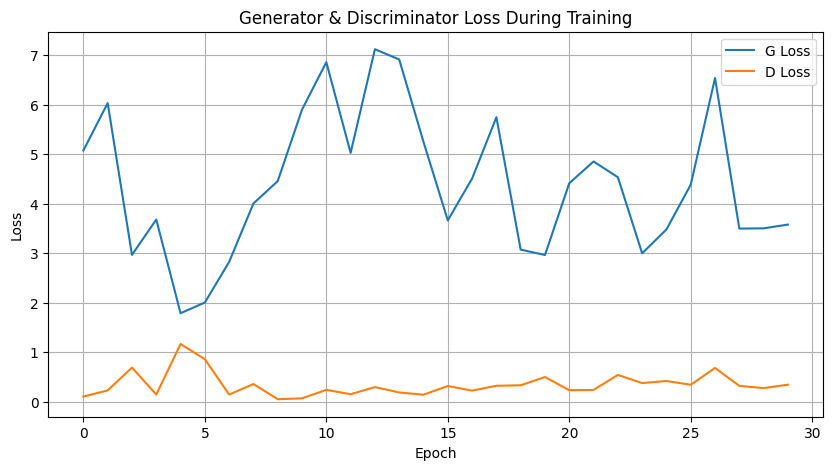

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(G_losses, label="G Loss")
plt.plot(D_losses, label="D Loss")
plt.title("Generator & Discriminator Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [31]:
torch.save(G.state_dict(), "generator.pth")
torch.save(D.state_dict(), "discriminator.pth")
torch.save(G.state_dict(), "/kaggle/working/generator.pth")
torch.save(D.state_dict(), "/kaggle/working/discriminator.pth")